<a href="https://colab.research.google.com/github/kzdanowski/KGN_Programowanie2/blob/main/Lab%5CP2Lab11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progamowanie 2, Laboratorium 11

## 1. Regresja liniowa i wielomianowa

Regresja wielomianowa jest realizowana przez stworzenie w PolynomialFeatures kolumn postaci X^n i wykonaniu regresji liniowej.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline

np.random.seed(0)
X = np.sort(np.random.uniform(0, 10, 20))[:, np.newaxis]
y = np.sin(X).ravel() + np.random.normal(0, 0.3, X.shape[0])

X_plot = np.linspace(0, 10, 200)[:, np.newaxis]

# TODO: Zaimplementuj modele i narysuj ich predykcje na X_plot

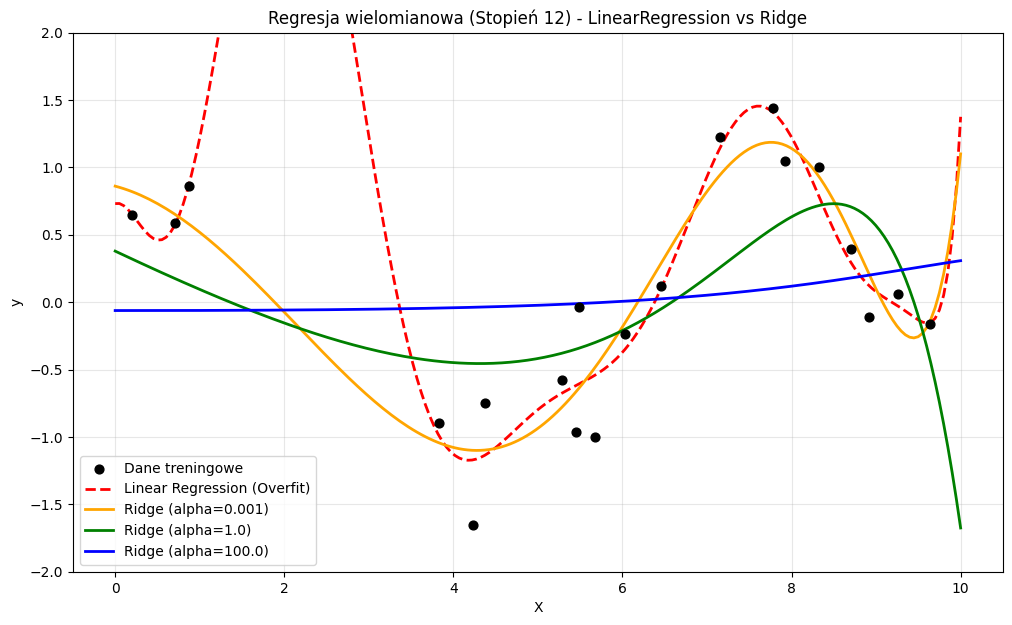

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Generowanie danych
np.random.seed(0)
X = np.sort(np.random.uniform(0, 10, 20))[:, np.newaxis]
y = np.sin(X).ravel() + np.random.normal(0, 0.3, X.shape[0])

X_plot = np.linspace(0, 10, 200)[:, np.newaxis]

# Konfiguracja wykresu
plt.figure(figsize=(12, 7))
plt.scatter(X, y, color='black', s=40, label='Dane treningowe', zorder=10)

# Model 1: Zwykła regresja liniowa (Overfitting)
poly_lr = make_pipeline(PolynomialFeatures(12),  LinearRegression())
poly_lr.fit(X, y)
plt.plot(X_plot, poly_lr.predict(X_plot), color='red', linestyle='--',
         linewidth=2, label='Linear Regression (Overfit)')

# Modele 2: Regresja Ridge z różnymi wartościami alpha
alphas = [0.001, 1.0, 100.0]
colors = ['orange', 'green', 'blue']

for alpha, color in zip(alphas, colors):
    poly_ridge = make_pipeline(PolynomialFeatures(12), StandardScaler(), Ridge(alpha=alpha))
    poly_ridge.fit(X, y)
    plt.plot(X_plot, poly_ridge.predict(X_plot), color=color,
             linewidth=2, label=f'Ridge (alpha={alpha})')

plt.ylim(-2, 2) # Ograniczamy oś Y, LinearRegression może przyjmować duże wartości
plt.title('Regresja wielomianowa (Stopień 12) - LinearRegression vs Ridge')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Klasteryzacja (KMeans, DBSCAN)

Wykonaj klasteryzację i wizualizację wygenrowanych niżej danych.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN

# --- Generowanie danych ---
# 3 gęste skupiska (300 punktów)
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=0)

# 100 punktów jednostajnego szumu
rng = np.random.RandomState(42)
X_noise = rng.uniform(low=-8, high=8, size=(100, 2))

# Połączony zbiór
X_combined = np.vstack([X_blobs, X_noise])

# --- Trenowanie modeli ---
# KMeans (zakładamy, że wiemy o 3 klastrach)

# Maska dla szumu w modelu y_dbscan
# noise_mask = (y_dbscan == -1)
# core_mask = ~noise_mask



## 3. Klasyfikacja dwóch współśrodkowych okręgów (KMeans, DBSCAN)

Porównaj dwie metody klasyfikacji na poniżej wygenerowanych danych. Narysuj oba klasyfikatory.

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import numpy as np

# Generowanie dwóch koncentrycznych okręgów z drobnym szumem
X, _ = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)

plt.figure(figsize=(12, 5))

# Model 1: KMeans

# Model 2: DBSCAN
# Dobierz parametry: eps i min_samples


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

## 4. Dane z jedną dużą klasą (95%)i drugą małą.

Wytrenuj model na poniższych danych. Sprawdź jego błąd. Sprawdź jak błąd zachowuje się na dwóch klasach. Jak poprawić jego zachowanie?

In [5]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Generujemy 1000 próbek, gdzie klasa '1' to tylko 5% całości (np. rzadka choroba)
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.95, 0.05],
                           random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# TODO: Wytrenuj klasyfikator LogisticRegression
# TODO: Oblicz predykcje dla X_test

## 5. Dane, w których tylko część cech ma wpływ na wartość celu.

Sprawdzamy, czy model samodzielnie odrzuci nieistotne cechy.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Generujemy dane z 20 cechami (kolumnami), ale TYLKO 3 z nich mają faktyczny wpływ na 'y'.
# Pozostałe 17 to czysty, losowy szum.
X, y = make_regression(n_samples=500, n_features=20, n_informative=3,
                       noise=10.0, random_state=42)

# TODO: Wytrenuj modele DecisionTreeRegressor i RandomForestRegressor na całych danych (X, y)
# RandomForestRegressor zawiera wektor model.feature_importances_ istotności cech.
# Stwórz wykres słupkowy istotności cech.

## 6. Klasyfikcja danych z szumem

Narysuj wykresy punktowe klasyfikacji KMeans oraz DBSCAN. Porównaj ich działanie.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generujemy 3 gęste, idealne skupiska (300 punktów)
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=0)

# Generujemy 100 punktów "śmieci" (szum jednostajny) rozsianych po całym obszarze
rng = np.random.RandomState(42)
X_noise = rng.uniform(low=-8, high=8, size=(100, 2))

# Łączymy "dobre" dane i "śmieci" w jedną wielką tablicę
X_combined = np.vstack([X_blobs, X_noise])

# TODO: Narysuj najpierw X_combined na wykresie punktowym, by zobaczyć jak wyglądają dane
# TODO: Zastosuj KMeans(n_clusters=3) na X_combined
# centers = kmeans.cluster_centers_
# TODO: Zastosuj DBSCAN(eps=0.8, min_samples=5) na X_combined
# y_dbscan = dbscan.fit_predict(X_combined)
# noise_mask = (y_dbscan == -1)
# core_mask = ~noise_mask